Задание 1:

In [12]:
import numpy as np

rng = np.random.default_rng(42)
arr = rng.integers(0, 100, size=(4, 5))

print('Исходный массив')
print(arr)

print('\nТранспонирование')
print(arr.T)

print('\nФильтрация')
print(arr[arr > 50])

arr_norm = (arr - arr.min()) / (arr.max() - arr.min())
print('\nПреобразование')
print(np.round(arr_norm, 3))

print('\nСумма по строкам:')
print(arr.sum(axis=1))

print('\nМатричное умножение')
print(arr @ arr.T)

Исходный массив
[[ 8 77 65 43 43]
 [85  8 69 20  9]
 [52 97 73 76 71]
 [78 51 12 83 45]]

Транспонирование
[[ 8 85 52 78]
 [77  8 97 51]
 [65 69 73 12]
 [43 20 76 83]
 [43  9 71 45]]

Фильтрация
[77 65 85 69 52 97 73 76 71 78 51 83]

Преобразование
[[0.    0.775 0.64  0.393 0.393]
 [0.865 0.    0.685 0.135 0.011]
 [0.494 1.    0.73  0.764 0.708]
 [0.787 0.483 0.045 0.843 0.416]]

Сумма по строкам:
[236 191 369 269]

Матричное умножение
[[13916  7028 18951 10835]
 [ 7028 12531 12392  9931]
 [18951 12392 28259 19382]
 [10835  9931 19382 17743]]


Задание 2:

Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Координаты: (258, 488) (718, 1098)


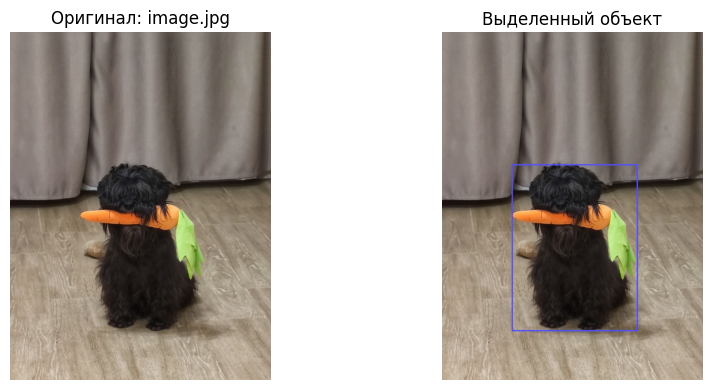

In [ ]:
import cv2
import matplotlib.pyplot as plt

image_path = "image.jpg"
image_bgr = cv2.imread(image_path)

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

x, y, w, h = cv2.selectROI('Enter', image_bgr, showCrosshair=True, fromCenter=False)
cv2.destroyAllWindows()
x, y, w, h = map(int, [x, y, w, h])
x1, y1, x2, y2 = x, y, x + w, y + h

result = image_bgr.copy()
cv2.rectangle(result, (x1, y1), (x2, y2), (255, 80, 80), 4)
print('Координаты:', (x1, y1), (x2, y2))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title(f'Оригинал: {image_path}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Выделенный объект')
plt.axis('off')

plt.tight_layout()
plt.show()

Задание 3:

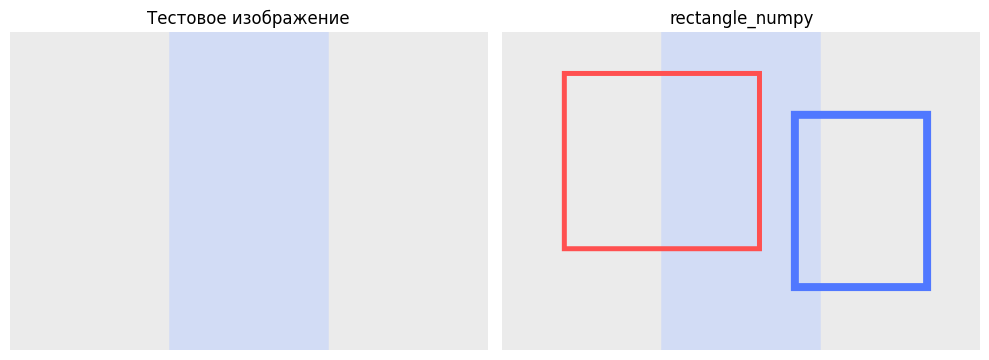

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def rectangle_numpy(img, pt1, pt2, color=(255, 0, 0), thickness=3):
    out = img.copy()
    h, w = out.shape[:2]

    x1, y1 = pt1
    x2, y2 = pt2
    x1, x2 = sorted((x1, x2))
    y1, y2 = sorted((y1, y2))

    x1 = max(0, min(x1, w - 1))
    x2 = max(0, min(x2, w - 1))
    y1 = max(0, min(y1, h - 1))
    y2 = max(0, min(y2, h - 1))

    for t in range(thickness):
        yt = y1 + t
        yb = y2 - t
        xl = x1 + t
        xr = x2 - t

        if yt <= yb and xl <= xr:
            out[yt, xl:xr + 1] = color
            out[yb, xl:xr + 1] = color
            out[yt:yb + 1, xl] = color
            out[yt:yb + 1, xr] = color

    return out

canvas = np.full((320, 480, 3), 235, dtype=np.uint8)
canvas[:, 160:320] = [210, 220, 245]
result = rectangle_numpy(canvas, (60, 40), (260, 220), color=(255, 80, 80), thickness=5)
result = rectangle_numpy(result, (290, 80), (430, 260), color=(80, 120, 255), thickness=8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(canvas)
plt.title('Тестовое изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title('rectangle_numpy')
plt.axis('off')

plt.tight_layout()
plt.show()